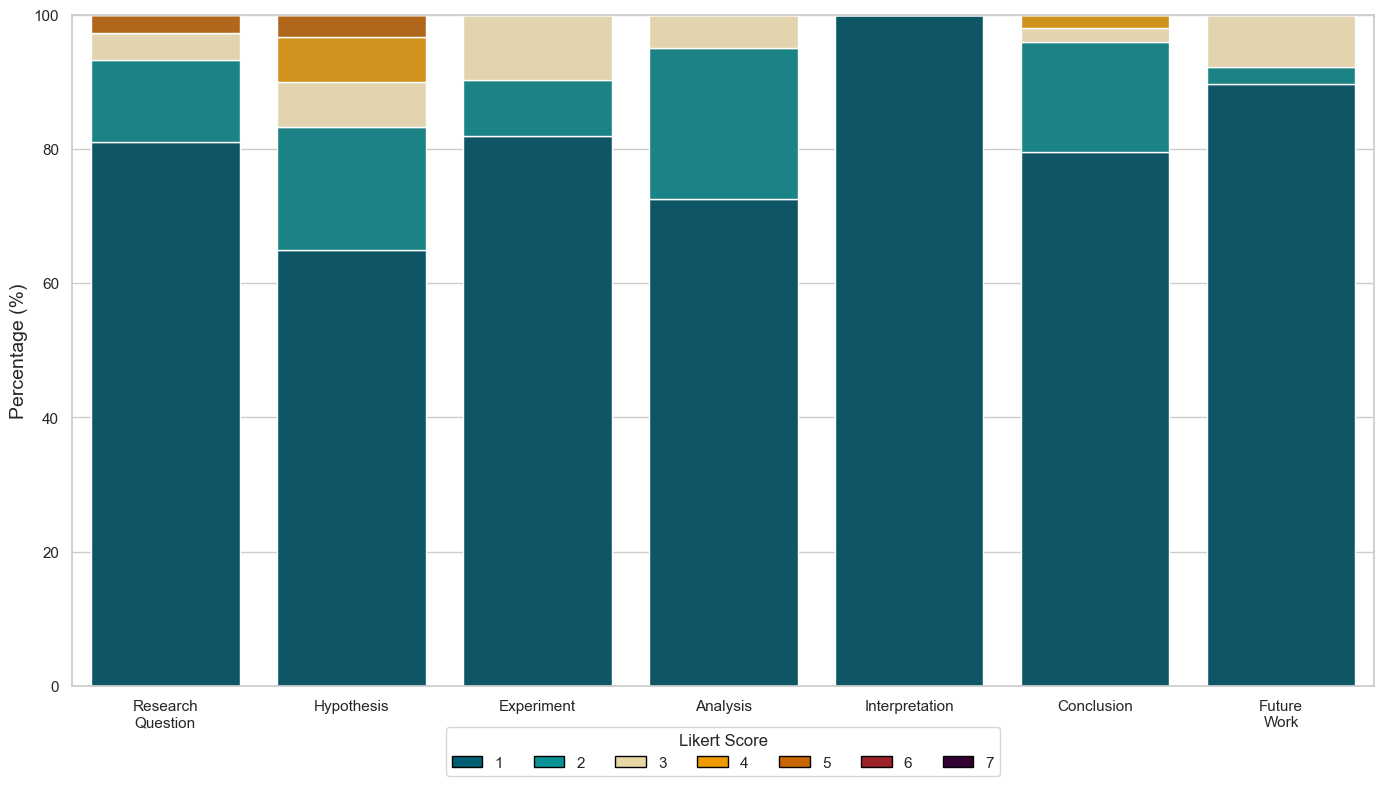

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Load the dataframe from your csv file
file_path = 'output.csv'
df = pd.read_csv(file_path)

# --- Data Transformation for 100% Stacked Bar Chart ---

# 1. Map original field names to new, shorter names
# 1. Map original field names to new, shorter names, grouping suggestions
#    into 'Future Work'.
field_mapping = {
    'Research Question Likert Score': 'Research\nQuestion',
    'Hypothesis Likert Score': 'Hypothesis',
    'Experiment Description Likert Score': 'Experiment',
    'Analysis Likert Score': 'Analysis',
    'Interpretation Likert Score': 'Interpretation',
    'Conclusion Likert Score': 'Conclusion',
    'Suggested Research Question Likert Score': 'Future\nWork',
    'Suggested Hypothesis Likert Score': 'Future\nWork'
}
df['section'] = df['section'].map(field_mapping)

# 2. Define the desired order for the fields
field_order = [
    'Research\nQuestion',
    'Hypothesis',
    'Experiment',
    'Analysis',
    'Interpretation',
    'Conclusion',
    'Future\nWork'
]

# Create a cross-tabulation to count occurrences of each Likert 'value' for each 'section'
counts_df = pd.crosstab(df['section'], df['value'])

# 3. Reorder the DataFrame according to the specified field_order
#    and ensure all Likert values (1-7) are present as columns.
counts_df = counts_df.reindex(field_order, fill_value=0).reindex(columns=range(1, 8), fill_value=0)

# Calculate the percentage of each Likert score for each field
percentages_df = counts_df.div(counts_df.sum(axis=1), axis=0) * 100

# --- Plotting ---

# Set up the plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# Create the 100% stacked bar chart
# The `bottom` parameter is updated in each iteration to stack the bars
bottom = pd.Series([0.0] * len(percentages_df), index=percentages_df.index)

# 4. Use a distinct, perceptually uniform Green-to-Red color palette
colors = [
    "#005f73",  # 1: Deep Ocean Blue/Teal (Highly distinct from 2)
    "#0a9396",  # 2: Vibrant Turquoise 
    "#e9d8a6",  # 3: Muted Straw Yellow (No longer "blinding" bright yellow)
    "#ee9b00",  # 4: Deep Amber
    "#ca6702",  # 5: Rust Red (Your distinct "Bad" anchor)
    "#9b2226",  # 6: Maroon
    "#330033"   # 7: Dark Purple
]

for i, col in enumerate(percentages_df.columns):
    ax = sns.barplot(
        x=percentages_df.index,
        y=percentages_df[col],
        color=colors[i],
        label=col,
        bottom=bottom
    )
    # Update the bottom for the next stack
    bottom += percentages_df[col]

# --- Formatting and Labels ---

# Add titles and labels for clarity
#ax.set_title('Likert Scale Distribution per Field', fontsize=18)
ax.set_xlabel(None)
ax.set_ylabel('Percentage (%)', fontsize=14)

# Define full set of possible labels
all_legend_labels = {
    1: "1 - Nearly Perfect",
    2: "2 - Correct",
    3: "3 - Acceptable",
    4: "4 - Partially Incorrect",
    5: "5 - Incorrect",
    6: "6 - No overlap",
    7: "7 - Hallucinatory"
}

# Create legend handles and labels for all possible scores (1-7)
legend_handles = []
legend_labels = []
for score in range(1, 8):
    legend_handles.append(Patch(facecolor=colors[score-1], edgecolor='black', label=str(score)))
    legend_labels.append(str(score))

# Add a legend with custom handles to ensure colors are displayed correctly
#ax.legend(handles=legend_handles, labels=legend_labels, title='Likert Score', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.legend(handles=legend_handles, title='Likert Score', loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=len(legend_labels))
# Ensure the layout is tight
plt.tight_layout()

# Display the plot
plt.savefig(f"plots/likert_scale_bars.pdf", dpi=6000)
plt.show()
